In [1]:
# Analisis exploratorio del dataset de potencial energetico.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

try:
    df = pd.read_csv('../data/processed/final_dataset_ecuador.csv')
    print("[OK] Dataset final cargado exitosamente.")
    print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")
except FileNotFoundError:
    print("[ERROR] Error: No se encontro el archivo 'final_dataset_ecuador.csv'. Asegurate de haber ejecutado el paso anterior.")
    exit()

print("\n--- Primeras 5 filas del Dataset ---")
print(df.head())

print("\n--- Informacion general del Dataset (df.info()) ---")
df.info()

print("\n--- Estadisticas descriptivas del Dataset ---")
print(df.describe())

[OK] Dataset final cargado exitosamente.
El dataset tiene 288 filas y 10 columnas.

--- Primeras 5 filas del Dataset ---
  provincia  latitude  longitude  month  temp_avg  wind_speed_avg  \
0     Azuay   -2.9006    -79.004      1   11.5773          1.8933   
1     Azuay   -2.9006    -79.004      2   12.0730          1.5313   
2     Azuay   -2.9006    -79.004      3   12.3677          1.4574   
3     Azuay   -2.9006    -79.004      4   11.8671          1.6135   
4     Azuay   -2.9006    -79.004      5   11.5593          1.8098   

   humidity_avg  target_solar_kwh_per_m2  target_wind_mwh  target_hydro_mwh  
0       88.3806                  18.7648          53.6837         6852.7414  
1       87.4912                  17.1785          25.5508         8311.9789  
2       86.3080                  21.4602          24.5915        11468.7961  
3       88.6220                  18.1111          32.2810         8469.2523  
4       85.7130                  20.9756          42.0964         5323.784

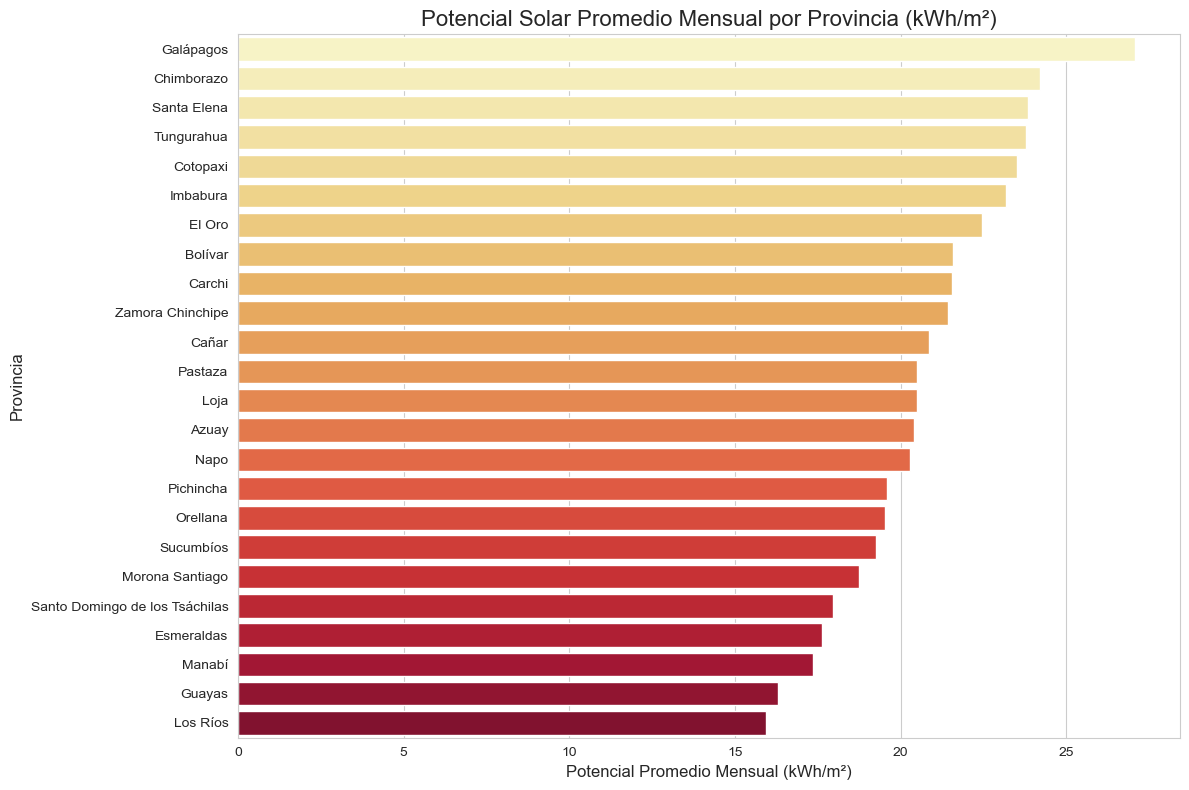

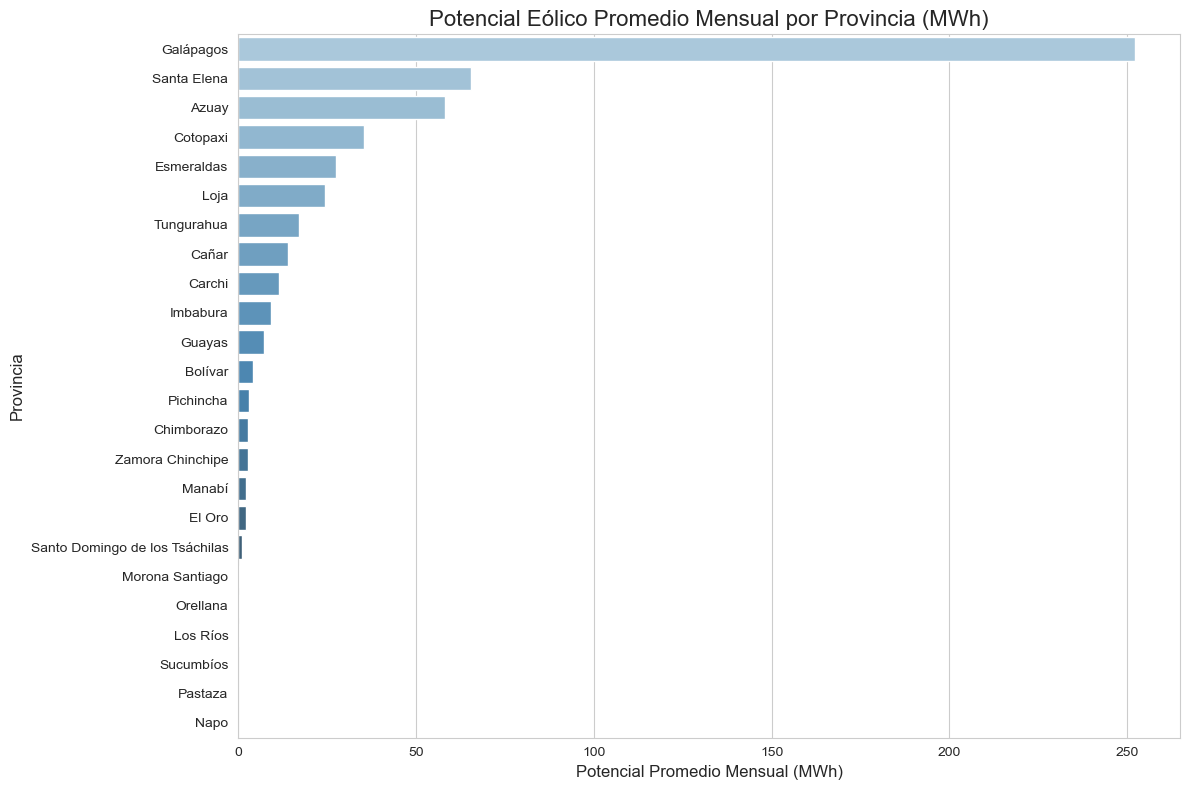

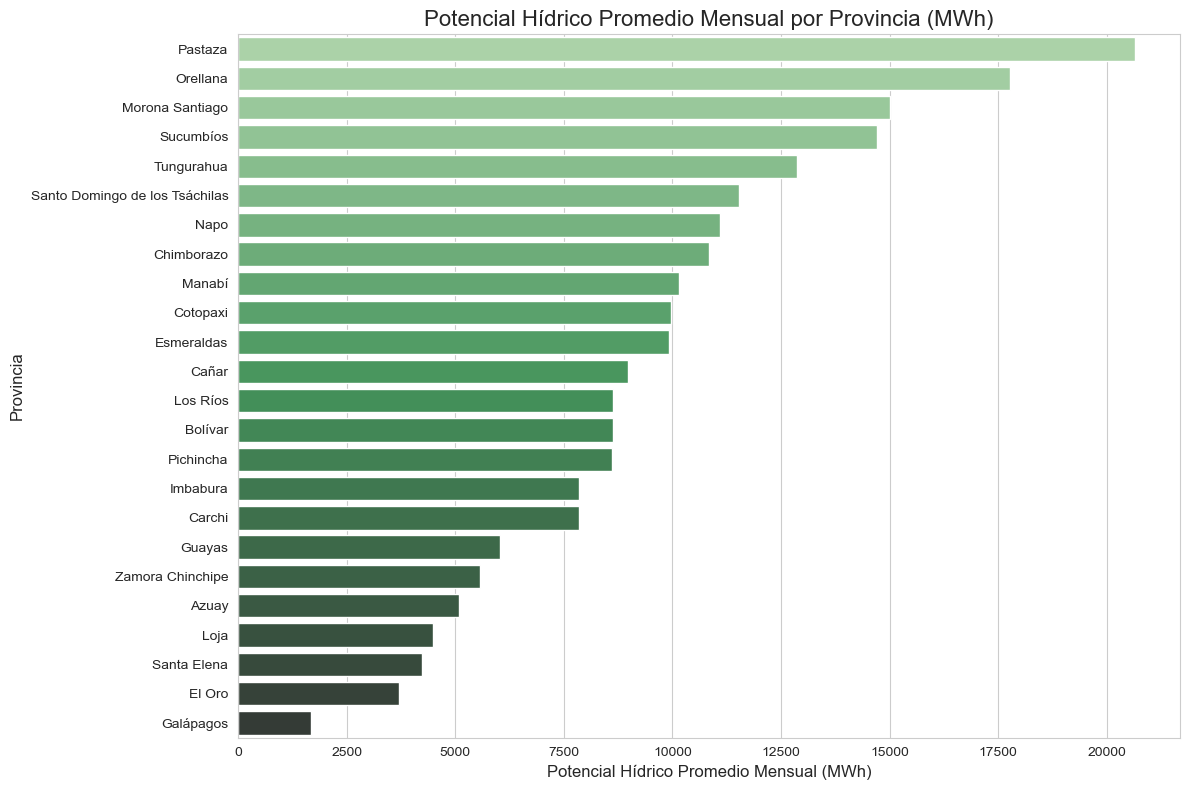

In [2]:
# Desglose del potencial energético por tecnología renovable.

# Agregación provincial para obtener promedios anuales.
# Promedio mensual multianual calculado con función de media.
potencial_por_provincia = df.groupby('provincia')[['target_solar_kwh_per_m2', 'target_wind_mwh', 'target_hydro_mwh']].mean()

# Orden descendente para facilitar la interpretación visual.
potencial_solar = potencial_por_provincia['target_solar_kwh_per_m2'].sort_values(ascending=False)
potencial_eolico = potencial_por_provincia['target_wind_mwh'].sort_values(ascending=False)
potencial_hidrico = potencial_por_provincia['target_hydro_mwh'].sort_values(ascending=False)

# Visualización del potencial solar promedio por provincia.
plt.figure(figsize=(12, 8))
sns.barplot(x=potencial_solar.values, y=potencial_solar.index, hue=potencial_solar.index, palette='YlOrRd', legend=False)
plt.title('Potencial Solar Promedio Mensual por Provincia (kWh/m²)', fontsize=16)
plt.xlabel('Potencial Promedio Mensual (kWh/m²)', fontsize=12)
plt.ylabel('Provincia', fontsize=12)
plt.tight_layout()
plt.savefig('../docs/potencial_solar_por_provincia.png') # Guardar el gráfico
plt.show()

# Visualización del potencial eólico promedio por provincia.
plt.figure(figsize=(12, 8))
sns.barplot(x=potencial_eolico.values, y=potencial_eolico.index, hue=potencial_eolico.index, palette='Blues_d', legend=False)
plt.title('Potencial Eólico Promedio Mensual por Provincia (MWh)', fontsize=16)
plt.xlabel('Potencial Promedio Mensual (MWh)', fontsize=12)
plt.ylabel('Provincia', fontsize=12)
plt.tight_layout()
plt.savefig('../docs/potencial_eolico_por_provincia.png') # Guardar el gráfico
plt.show()

# Visualización del potencial hídrico promedio por provincia.
plt.figure(figsize=(12, 8))
sns.barplot(x=potencial_hidrico.values, y=potencial_hidrico.index, hue=potencial_hidrico.index, palette='Greens_d', legend=False)
plt.title('Potencial Hídrico Promedio Mensual por Provincia (MWh)', fontsize=16)
plt.xlabel('Potencial Hídrico Promedio Mensual (MWh)', fontsize=12)
plt.ylabel('Provincia', fontsize=12)
plt.tight_layout()
plt.savefig('../docs/potencial_hidrico_por_provincia.png') # Guardar el gráfico
plt.show()

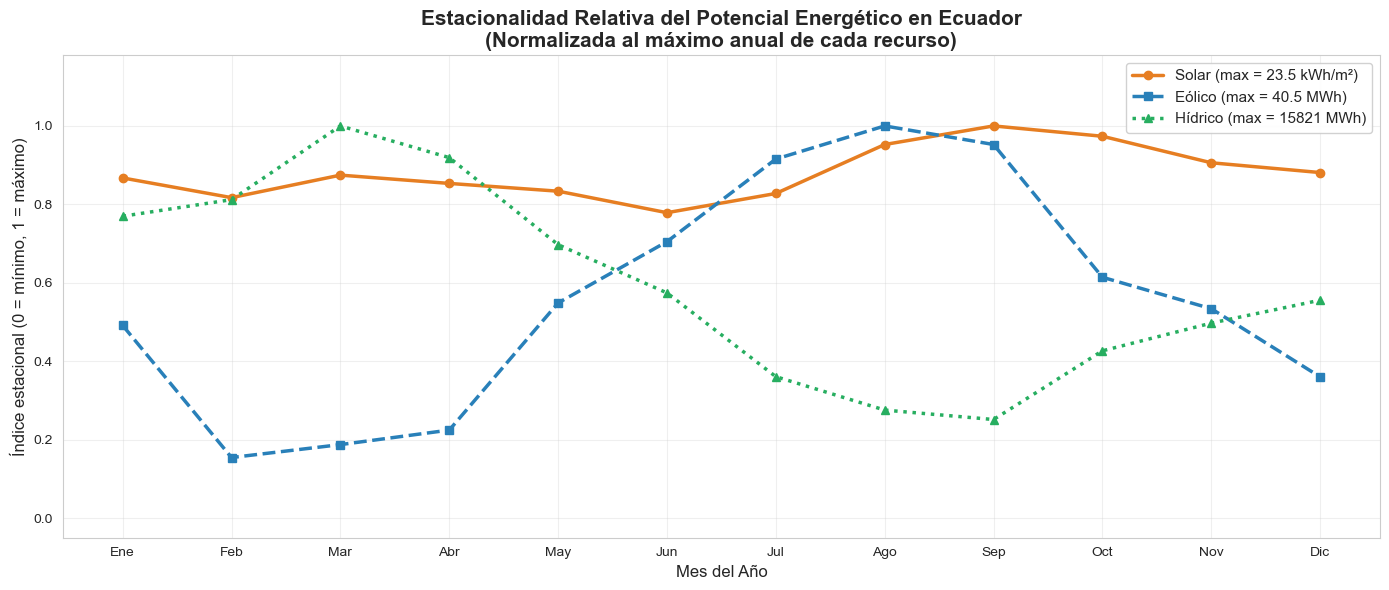

[OK] Estacionalidad normalizada guardada: docs/estacionalidad.png
  Solar:   pico en mes 9 (23.54 kWh/m²)
  Eolico:  pico en mes 8 (40.53 MWh)
  Hidrico: pico en mes 3 (15820.87 MWh)


In [3]:
# Evaluacion de patrones estacionales del potencial energetico.
# CORRECCION: version normalizada para evitar que el hidrico (~9400 MWh)
# aplaste visualmente al solar (~20 kWh/m2) y eolico (~22 MWh) en un solo eje Y.
# Cada serie se divide por su propio maximo -> escala 0-1 comparable.

potencial_por_mes = df.groupby('month')[['target_solar_kwh_per_m2',
                                         'target_wind_mwh',
                                         'target_hydro_mwh']].mean()

# Normalizar al maximo de cada recurso
pot_norm = potencial_por_mes.div(potencial_por_mes.max())

max_solar = potencial_por_mes['target_solar_kwh_per_m2'].max()
max_wind  = potencial_por_mes['target_wind_mwh'].max()
max_hydro = potencial_por_mes['target_hydro_mwh'].max()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(pot_norm.index, pot_norm['target_solar_kwh_per_m2'],
        marker='o', linestyle='-', color='#E67E22', lw=2.5,
        label=f'Solar (max = {max_solar:.1f} kWh/m²)')
ax.plot(pot_norm.index, pot_norm['target_wind_mwh'],
        marker='s', linestyle='--', color='#2980B9', lw=2.5,
        label=f'Eólico (max = {max_wind:.1f} MWh)')
ax.plot(pot_norm.index, pot_norm['target_hydro_mwh'],
        marker='^', linestyle=':', color='#27AE60', lw=2.5,
        label=f'Hídrico (max = {max_hydro:.0f} MWh)')

ax.set_title('Estacionalidad Relativa del Potencial Energético en Ecuador\n'
             '(Normalizada al máximo anual de cada recurso)',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Mes del Año', fontsize=12)
ax.set_ylabel('Índice estacional (0 = mínimo, 1 = máximo)', fontsize=12)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])
ax.set_ylim(-0.05, 1.18)
ax.legend(fontsize=11, loc='upper right', framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../docs/estacionalidad.png', dpi=150, bbox_inches='tight')
plt.savefig('../docs/estacionalidad_energetica.png', dpi=150, bbox_inches='tight')
plt.show()
print('[OK] Estacionalidad normalizada guardada: docs/estacionalidad.png')
print(f'  Solar:   pico en mes {pot_norm["target_solar_kwh_per_m2"].idxmax()} ({max_solar:.2f} kWh/m²)')
print(f'  Eolico:  pico en mes {pot_norm["target_wind_mwh"].idxmax()} ({max_wind:.2f} MWh)')
print(f'  Hidrico: pico en mes {pot_norm["target_hydro_mwh"].idxmax()} ({max_hydro:.2f} MWh)')

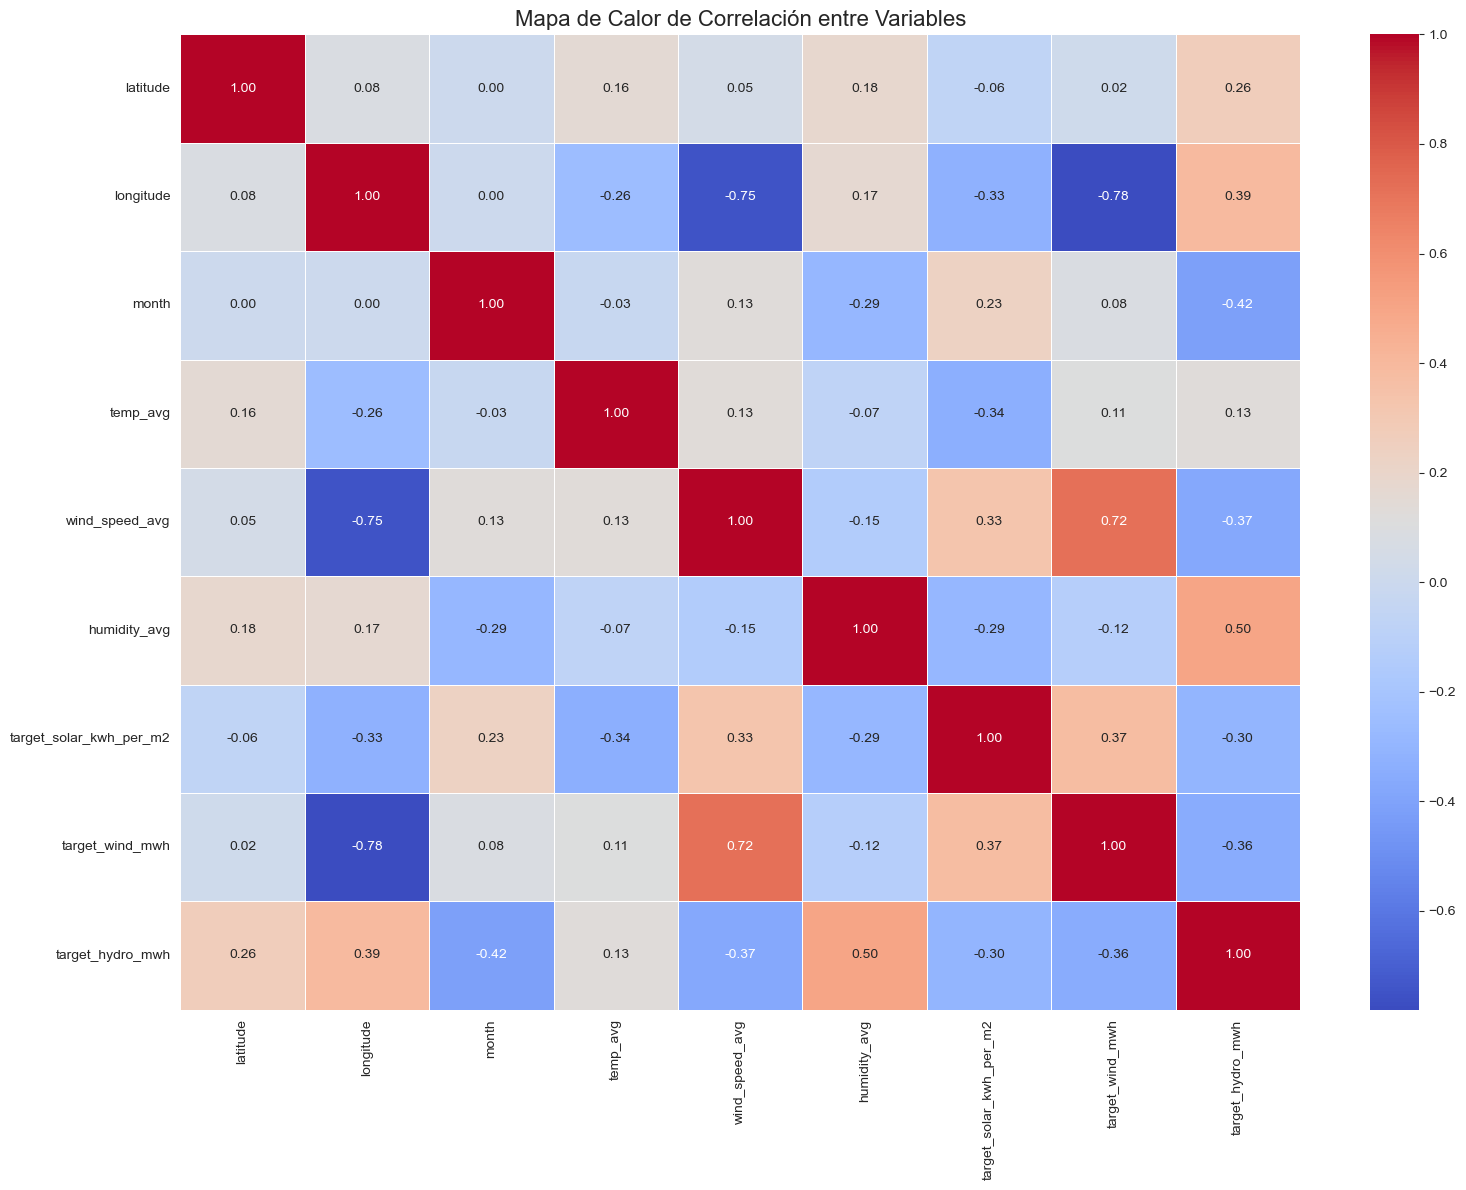


--- Correlación con el Potencial Solar ---
target_solar_kwh_per_m2    1.000000
target_wind_mwh            0.374743
wind_speed_avg             0.330725
month                      0.231864
latitude                  -0.064211
humidity_avg              -0.286569
target_hydro_mwh          -0.304156
longitude                 -0.328059
temp_avg                  -0.341202
Name: target_solar_kwh_per_m2, dtype: float64

--- Correlación con el Potencial Eólico ---
target_wind_mwh            1.000000
wind_speed_avg             0.721760
target_solar_kwh_per_m2    0.374743
temp_avg                   0.109186
month                      0.082917
latitude                   0.017904
humidity_avg              -0.123951
target_hydro_mwh          -0.355435
longitude                 -0.780134
Name: target_wind_mwh, dtype: float64

--- Correlación con el Potencial Hídrico ---
target_hydro_mwh           1.000000
humidity_avg               0.502006
longitude                  0.390367
latitude                 

In [4]:
# Análisis de correlación entre variables del dataset.

# Filtrado de columnas numéricas para la matriz de correlación.
df_numeric = df.select_dtypes(include=np.number)

# Cómputo de la matriz de coeficientes de correlación.
correlation_matrix = df_numeric.corr()

# Visualización termográfica de la matriz de correlación.
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Mapa de Calor de Correlación entre Variables', fontsize=16)
plt.tight_layout()
plt.savefig('../docs/mapa_correlacion.png') # Guardar el gráfico
plt.show()

# Correlación individual de cada variable objetivo con las características.
print("\n--- Correlación con el Potencial Solar ---")
print(correlation_matrix['target_solar_kwh_per_m2'].sort_values(ascending=False))

print("\n--- Correlación con el Potencial Eólico ---")
print(correlation_matrix['target_wind_mwh'].sort_values(ascending=False))

print("\n--- Correlación con el Potencial Hídrico ---")
print(correlation_matrix['target_hydro_mwh'].sort_values(ascending=False))

[OK] GeoJSON local cargado: 24 provincias
Provincias con datos en el mapa: 24/24

Diagnostico Galapagos:
       nombre  target_solar_kwh_per_m2  target_wind_mwh  target_hydro_mwh
19  Galápagos                27.077725       252.195183       1685.284208


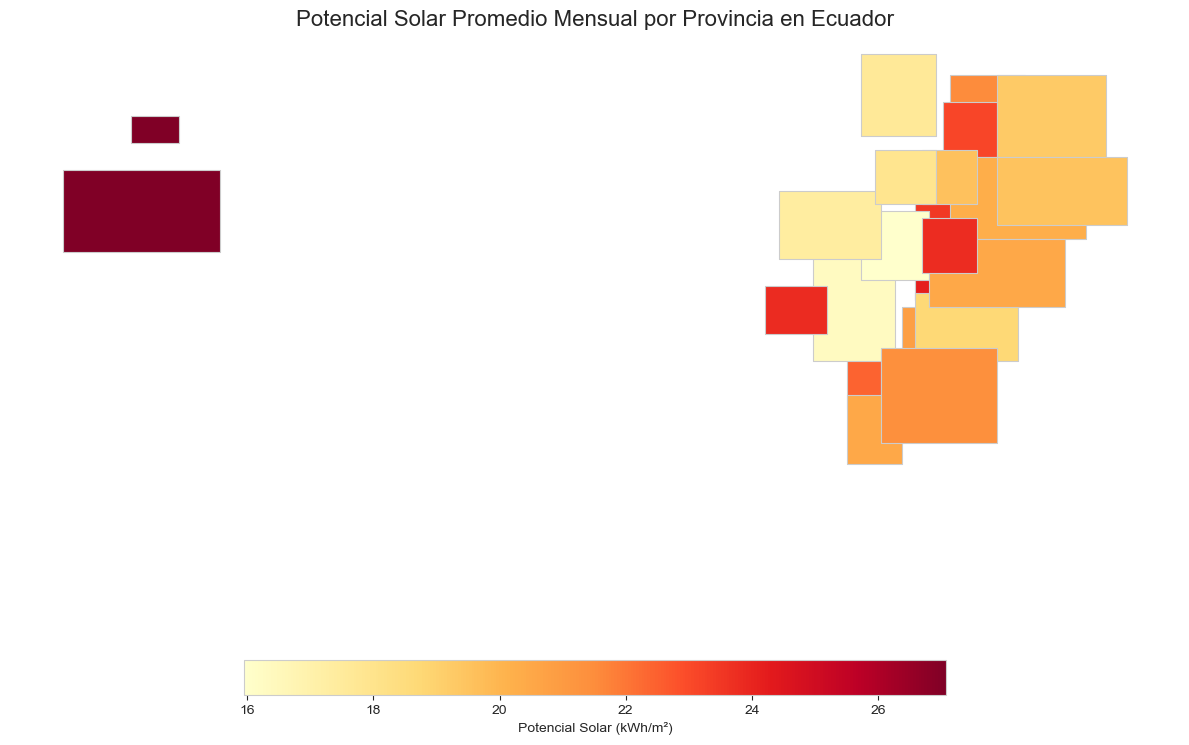

[OK] Mapa solar guardado


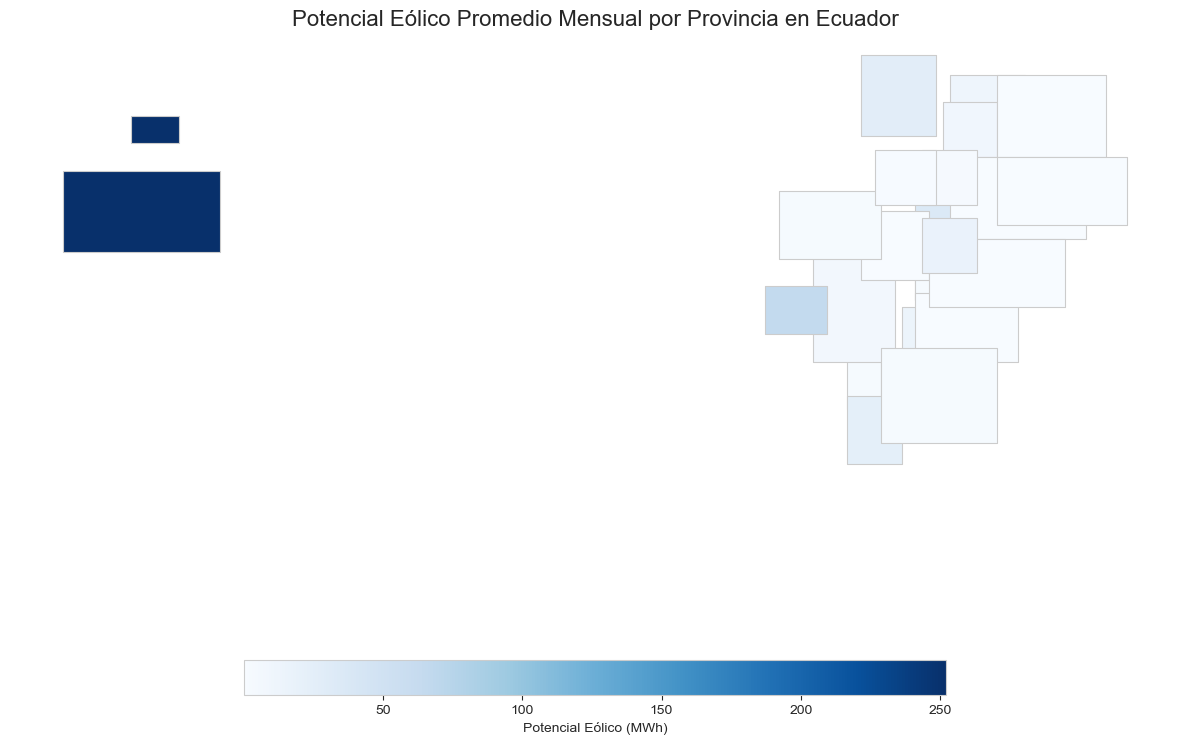

[OK] Mapa eolico guardado


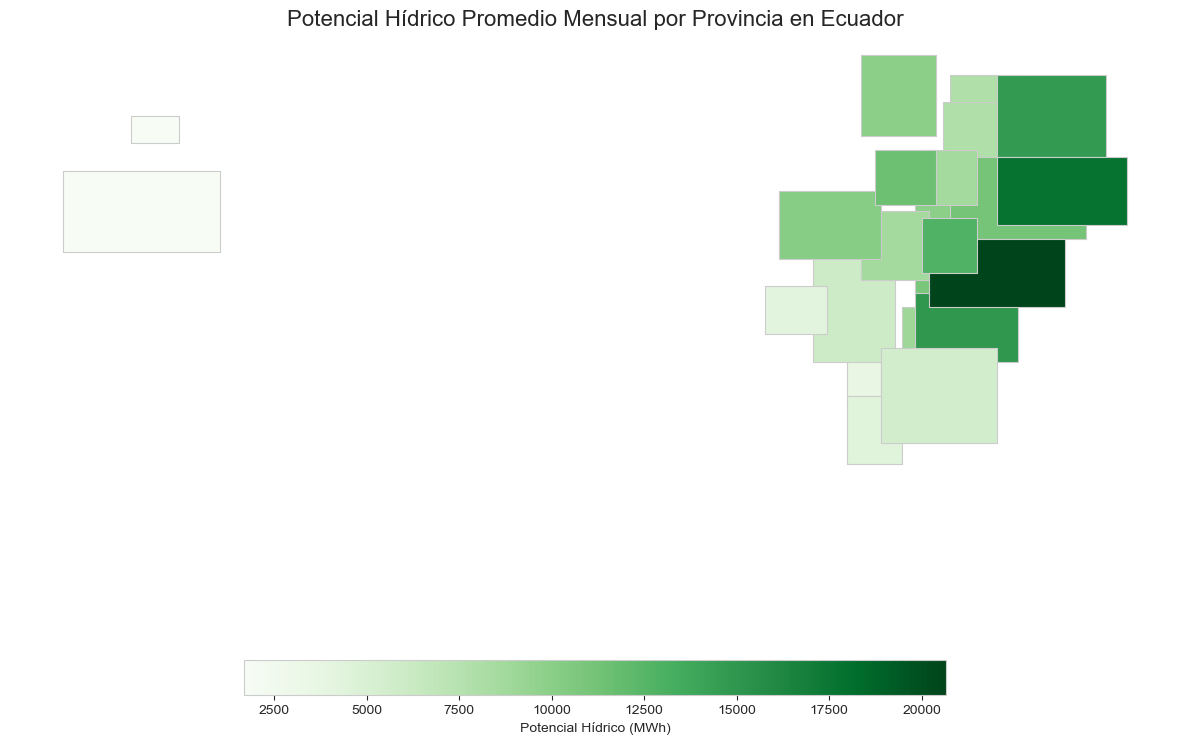

[OK] Mapa hidrico guardado


In [5]:
# Cartografia del potencial energetico por provincia.
# CORRECCION B: usa GeoJSON local (ecuador_provincias_poligonos.geojson)
# con nombres identicos al dataset -> merge directo sin ambiguedad.
# Incluye diagnostico de Galapagos antes de plotear.
import unicodedata

def normalizar(s):
    return unicodedata.normalize('NFD', str(s)).encode('ascii', 'ignore').decode('ascii').lower()

# --- Cargar GeoJSON local (24 provincias, columna 'nombre') ---
try:
    gdf_ecuador = gpd.read_file('../data/raw/ecuador_provincias_poligonos.geojson')
    print(f'[OK] GeoJSON local cargado: {len(gdf_ecuador)} provincias')
    nombre_col = 'nombre'
except FileNotFoundError:
    print('[AVISO] GeoJSON local no encontrado. Usando shapefile Natural Earth...')
    gdf_poligonos = gpd.read_file('../data/external/ne_10m_admin_1_states_provinces.shp')
    gdf_ecuador = gdf_poligonos[gdf_poligonos['admin'] == 'Ecuador'].copy()
    gdf_ecuador = gdf_ecuador.rename(columns={'name': 'nombre'})
    nombre_col = 'nombre'

# Normalizacion robusta para el merge (elimina tildes, minusculas)
gdf_ecuador['nombre_norm'] = gdf_ecuador[nombre_col].apply(normalizar)

potencial_promedio = df.groupby('provincia')[['target_solar_kwh_per_m2',
                                               'target_wind_mwh',
                                               'target_hydro_mwh']].mean().reset_index()
potencial_promedio['nombre_norm'] = potencial_promedio['provincia'].apply(normalizar)

gdf_con_potencial = gdf_ecuador.merge(potencial_promedio, on='nombre_norm', how='left')
n_match = gdf_con_potencial['target_solar_kwh_per_m2'].notna().sum()
print(f'Provincias con datos en el mapa: {n_match}/24')
if n_match < 24:
    shp_norms = set(gdf_ecuador['nombre_norm'])
    df_norms  = set(potencial_promedio['nombre_norm'])
    print('[AVISO] Solo en shapefile:', shp_norms - df_norms)
    print('[AVISO] Solo en dataset:',   df_norms - shp_norms)

# --- Diagnostico Galapagos (verificar que aparece en los 3 mapas) ---
gal_check = gdf_con_potencial[
    gdf_con_potencial[nombre_col].str.contains('Galápagos|Galapagos', case=False, na=False)
]
print('\nDiagnostico Galapagos:')
print(gal_check[[nombre_col, 'target_solar_kwh_per_m2',
                 'target_wind_mwh', 'target_hydro_mwh']].to_string())

# ----------------------------------------------------------------
# Mapa solar
# ----------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
gdf_con_potencial.plot(column='target_solar_kwh_per_m2', cmap='YlOrRd',
    linewidth=0.8, ax=ax, edgecolor='0.8', legend=True,
    missing_kwds={'color': 'lightgrey', 'label': 'Sin datos'},
    legend_kwds={'label': 'Potencial Solar (kWh/m²)',
                 'orientation': 'horizontal', 'shrink': 0.6})
ax.set_title('Potencial Solar Promedio Mensual por Provincia en Ecuador', fontsize=16)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('../docs/mapa_potencial_solar_ecuador.png', dpi=200, bbox_inches='tight')
plt.show()
print('[OK] Mapa solar guardado')

# ----------------------------------------------------------------
# Mapa eolico
# ----------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
gdf_con_potencial.plot(column='target_wind_mwh', cmap='Blues',
    linewidth=0.8, ax=ax, edgecolor='0.8', legend=True,
    missing_kwds={'color': 'lightgrey', 'label': 'Sin datos'},
    legend_kwds={'label': 'Potencial Eólico (MWh)',
                 'orientation': 'horizontal', 'shrink': 0.6})
ax.set_title('Potencial Eólico Promedio Mensual por Provincia en Ecuador', fontsize=16)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('../docs/mapa_potencial_eolico_ecuador.png', dpi=200, bbox_inches='tight')
plt.show()
print('[OK] Mapa eolico guardado')

# ----------------------------------------------------------------
# Mapa hidrico
# ----------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
gdf_con_potencial.plot(column='target_hydro_mwh', cmap='Greens',
    linewidth=0.8, ax=ax, edgecolor='0.8', legend=True,
    missing_kwds={'color': 'lightgrey', 'label': 'Sin datos'},
    legend_kwds={'label': 'Potencial Hídrico (MWh)',
                 'orientation': 'horizontal', 'shrink': 0.6})
ax.set_title('Potencial Hídrico Promedio Mensual por Provincia en Ecuador', fontsize=16)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('../docs/mapa_potencial_hidrico_ecuador.png', dpi=200, bbox_inches='tight')
plt.show()
print('[OK] Mapa hidrico guardado')

In [6]:
# === BLOQUE DE DIAGNÓSTICO (no forma parte del pipeline principal) ===
# Bloque de diagnostico de la capa geoespacial.

import geopandas as gpd

try:
    gdf_poligonos = gpd.read_file('../data/external/ne_10m_admin_1_states_provinces.shp')
    print("[OK] Shapefile cargado.")
except Exception as e:
    print(f"[ERROR] Error al cargar el shapefile: {e}")
    exit()

print("\n--- Columnas encontradas en el Shapefile ---")
print(gdf_poligonos.columns.tolist())

if 'admin' in gdf_poligonos.columns:
    print("\n--- Valores unicos en la columna 'admin' ---")
    print(gdf_poligonos['admin'].unique())
elif 'ADM0NAME' in gdf_poligonos.columns:
    print("\n--- Valores unicos en la columna 'ADM0NAME' ---")
    print(gdf_poligonos['ADM0NAME'].unique())
else:
    print("\n[AVISO] No se encontraron las columnas 'admin' o 'ADM0NAME'.")

if 'NAME_1' in gdf_poligonos.columns:
    print("\n--- Valores unicos en la columna 'NAME_1' (primeros 10) ---")
    print(gdf_poligonos['NAME_1'].unique()[:10])
elif 'name' in gdf_poligonos.columns:
    print("\n--- Valores unicos en la columna 'name' (primeros 10) ---")
    print(gdf_poligonos['name'].unique()[:10])
else:
    print("\n[AVISO] No se encontraron las columnas 'NAME_1' o 'name'.")

[OK] Shapefile cargado.

--- Columnas encontradas en el Shapefile ---
['featurecla', 'scalerank', 'adm1_code', 'diss_me', 'iso_3166_2', 'wikipedia', 'iso_a2', 'adm0_sr', 'name', 'name_alt', 'name_local', 'type', 'type_en', 'code_local', 'code_hasc', 'note', 'hasc_maybe', 'region', 'region_cod', 'provnum_ne', 'gadm_level', 'check_me', 'datarank', 'abbrev', 'postal', 'area_sqkm', 'sameascity', 'labelrank', 'name_len', 'mapcolor9', 'mapcolor13', 'fips', 'fips_alt', 'woe_id', 'woe_label', 'woe_name', 'latitude', 'longitude', 'sov_a3', 'adm0_a3', 'adm0_label', 'admin', 'geonunit', 'gu_a3', 'gn_id', 'gn_name', 'gns_id', 'gns_name', 'gn_level', 'gn_region', 'gn_a1_code', 'region_sub', 'sub_code', 'gns_level', 'gns_lang', 'gns_adm1', 'gns_region', 'min_label', 'max_label', 'min_zoom', 'wikidataid', 'name_ar', 'name_bn', 'name_de', 'name_en', 'name_es', 'name_fr', 'name_el', 'name_hi', 'name_hu', 'name_id', 'name_it', 'name_ja', 'name_ko', 'name_nl', 'name_pl', 'name_pt', 'name_ru', 'name_sv', 